### **Yogyakarta's Air Quality Dataset in December 2021**

In [1]:
import pandas as pd

df = pd.read_csv("12-jogja-dec-2021.csv")
print(df.shape)  # (jumlah baris, jumlah kolom)
df.index = df.index + 1
df.head(744)

(744, 11)


,Date,Time,PM10,PM2.5,SO2,CO,O3,NO2,Max,Critical Component,Category
1,12/1/2021,00:00:00,26.0,38.0,25.0,19.0,36.0,0.0,38,PM2.5,Good
2,12/1/2021,01:00:00,24.0,36.0,24.0,18.0,37.0,0.0,37,O3,Good
3,12/1/2021,02:00:00,23.0,34.0,23.0,18.0,38.0,0.0,38,O3,Good
4,12/1/2021,03:00:00,18.0,31.0,23.0,17.0,39.0,0.0,39,O3,Good
5,12/1/2021,04:00:00,17.0,31.0,22.0,17.0,40.0,0.0,40,O3,Good
...,...,...,...,...,...,...,...,...,...,...,...
740,12/31/2021,19:00:00,15.0,0.0,10.0,21.0,1.0,11.0,21,CO,Good
741,12/31/2021,20:00:00,16.0,0.0,10.0,21.0,1.0,11.0,21,CO,Good
742,12/31/2021,21:00:00,17.0,0.0,10.0,21.0,1.0,11.0,21,CO,Good
743,12/31/2021,22:00:00,18.0,0.0,10.0,21.0,1.0,11.0,21,CO,Good


#### <span style="color:blue">**Data Quality Check**</span>

In [2]:
filename = "12-jogja-dec-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df.info()                 # tipe data setiap kolom
df.isna().sum()           # jumlah data kosong per kolom
df.duplicated().sum()     # jumlah baris duplikat

Data source: 12-jogja-dec-2021.csv
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 744 entries, 0 to 743
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                744 non-null    object 
 1   Time                744 non-null    object 
 2   PM10                642 non-null    float64
 3   PM2.5               642 non-null    float64
 4   SO2                 642 non-null    float64
 5   CO                  642 non-null    float64
 6   O3                  642 non-null    float64
 7   NO2                 642 non-null    float64
 8   Max                 744 non-null    int64  
 9   Critical Component  642 non-null    object 
 10  Category            744 non-null    object 
dtypes: float64(6), int64(1), object(4)
memory usage: 64.1+ KB


np.int64(0)

#### <span style="color:blue">**Descriptive Statistics for Numerical Variables**</span>

In [3]:
filename = "12-jogja-dec-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
kolom = df["PM2.5"]
kolom.mean(), kolom.median(), kolom.mode()[0]
kolom.var(), kolom.std()
kolom.quantile(0.25), kolom.quantile(0.75)
df.describe()

Data source: 12-jogja-dec-2021.csv


,PM10,PM2.5,SO2,CO,O3,NO2,Max
count,642.000000,642.000000,642.000000,642.000000,642.000000,642.000000,744.000000
mean,18.478193,1.805296,12.147975,19.327103,8.862928,6.386293,20.919355
std,8.705638,6.643902,6.074029,2.783758,12.160647,4.800578,11.160228
min,8.000000,0.000000,1.000000,14.000000,0.000000,0.000000,0.000000
25%,13.000000,0.000000,8.000000,17.000000,1.000000,1.000000,18.000000
50%,17.000000,0.000000,11.000000,19.000000,3.000000,10.000000,20.000000
75%,19.750000,0.000000,17.000000,21.000000,9.000000,11.000000,26.000000
max,51.000000,38.000000,25.000000,26.000000,45.000000,12.000000,51.000000


#### <span style="color:blue">**Summary of Categorical Variables**</span>

##### <span style="color:blue">**1. Critical Component**</span>

In [4]:
filename = "12-jogja-dec-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df["Critical Component"].value_counts() # Display the raw counts for each
df["Critical Component"].value_counts(normalize=True) * 100 # Display the percentages for each

Data source: 12-jogja-dec-2021.csv


Critical Component
CO       59.034268
PM10     28.504673
O3       12.305296
PM2.5     0.155763
Name: proportion, dtype: float64

##### <span style="color:blue">**2. Category**</span>

In [5]:
filename = "12-jogja-dec-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")
df["Category"].value_counts() # Display the raw counts for each
df["Category"].value_counts(normalize=True) * 100 # Display the percentages for each


Data source: 12-jogja-dec-2021.csv


Category
Good        99.596774
Moderate     0.403226
Name: proportion, dtype: float64

#### <span style="color:blue">**Data Visualization**</span>

#### <span style="color:blue">**1. Line Graph**</span>

Data source: 12-jogja-dec-2021.csv


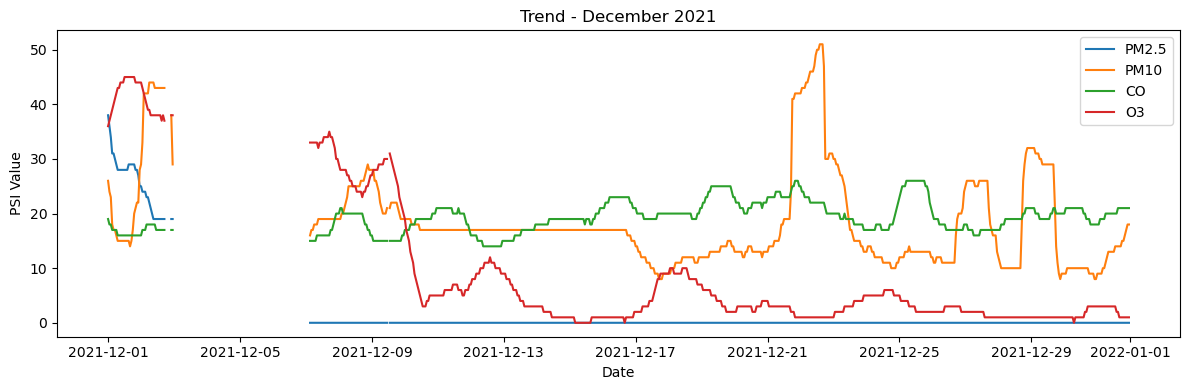

In [6]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "12-jogja-dec-2021.csv"
df = pd.read_csv(filename) # Read the CSV file for the October data
print(f"Data source: {filename}") # Display  the file being used

numeric_cols = ["PM2.5", "PM10", "CO", "O3"] # List the columns that will be compared

# Combine Date and Time into one "datetime" column, so the x-axis is ordered correctly
df["Date_Time"] = pd.to_datetime(df["Date"] + " " + df["Time"]) # Merge date and time into one column

plt.figure(figsize=(12, 4)) # Adjust the chart size (width 12, height 4)
for col in numeric_cols:
    plt.plot(df["Date_Time"], df[col], label=col) # Draw one line per column and give the label for each
    
plt.title("Trend - December 2021") # Title for the chart
plt.xlabel("Date") # x-axis label
plt.ylabel("PSI Value") # y-axis label
plt.legend() # A small labeled box that tells what each color and line represents
plt.xticks(rotation=0) # Tilt "or not" the data labels to prevent overlapping
plt.tight_layout() # Adjust the spacing so that the label doesn't get cut off
plt.show() # Display the chart

#### <span style="color:blue">**2. Boxplot**</span>

Data source: 12-jogja-dec-2021.csv


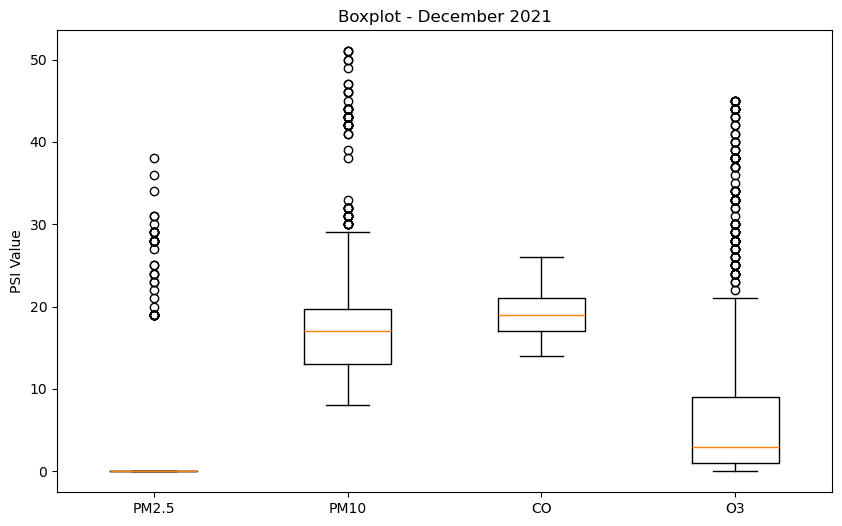

In [8]:
filename = "12-jogja-dec-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")

numeric_cols = ["PM2.5", "PM10", "CO", "O3"]

plt.figure(figsize=(10, 6))
plt.boxplot([df[col].dropna() for col in numeric_cols], tick_labels=numeric_cols)
plt.title("Boxplot - December 2021")
plt.ylabel("PSI Value")
plt.show()

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

#### <span style="color:blue">**3. Bar Chart**</span>

Data source: 12-jogja-dec-2021.csv


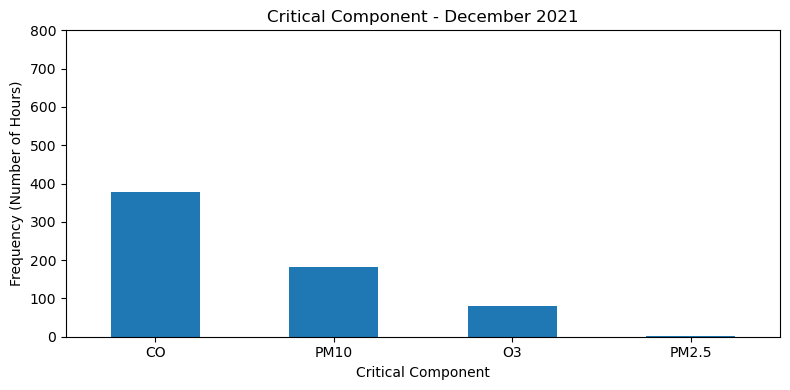

Critical Component
CO       379
PM10     183
O3        79
PM2.5      1
Name: count, dtype: int64

In [9]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "12-jogja-dec-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")

#Bar chart for the "Critical Component" column
plt.figure(figsize=(8, 4))
df ["Critical Component"].value_counts().plot(kind="bar")
plt.title("Critical Component - December 2021")
plt.xlabel("Critical Component")
plt.ylabel("Frequency (Number of Hours)")
plt.ylim(0, 800) # Limit the y-axis from 0 to 800
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

df["Critical Component"].value_counts() # Display the counts for each bar of Critical Component

Data source: 12-jogja-dec-2021.csv


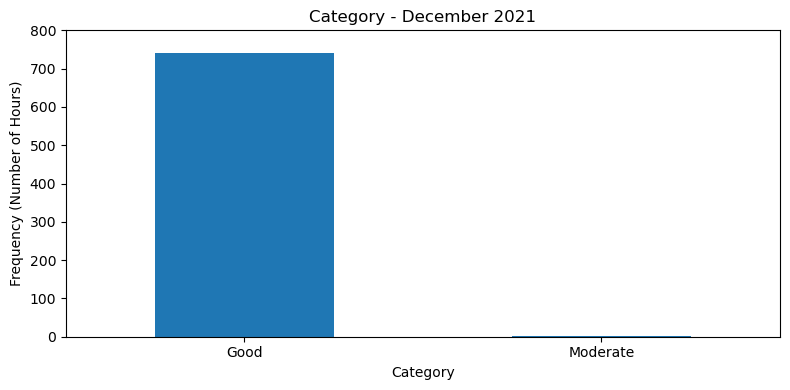

Category
Good        741
Moderate      3
Name: count, dtype: int64

In [10]:
import matplotlib.pyplot as plt
import pandas as pd

filename = "12-jogja-dec-2021.csv"
df = pd.read_csv(filename)
print(f"Data source: {filename}")

#Bar chart for the "Category" column
plt.figure(figsize=(8, 4))
df["Category"].value_counts().plot(kind="bar")
plt.title("Category - December 2021")
plt.xlabel("Category")
plt.ylabel("Frequency (Number of Hours)")
plt.ylim(0, 800) # Limit the y-axis from 0 to 800
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

df["Category"].value_counts() # Display the counts for each category